# **<center style="color: green;">Desafío - Predicción de churn</center>**

#### **Nombre:** Cristian Tobar Morales ###
#### **Curso:** Machine Learning ###

# **Descripción**
En la industria de las telecomunicaciones, la retención de clientes es un desafío clave para
las empresas. La fuga de clientes, también conocida como churn, es un problema que puede
tener un impacto significativo en los ingresos y la reputación de una empresa. Anticiparse a
la fuga de clientes y tomar medidas preventivas para retenerlos se ha convertido en una
prioridad estratégica. En este contexto, el objetivo de esta tarea es utilizar técnicas de
machine learning para desarrollar un modelo que pueda predecir la probabilidad de fuga de
clientes en una empresa de telecomunicaciones.

## El objetivo principal
Utilizar un enfoque basado en machine learning para
construir un modelo predictivo de fuga de clientes. El modelo será capaz de clasificar a los
clientes como "fugados" o "no fugados" en función de un conjunto de variables relevantes. El
objetivo es proporcionar a la empresa de telecomunicaciones una herramienta eficaz para
identificar a los clientes en riesgo de abandonar sus servicios, lo que permitirá tomar
medidas proactivas para retenerlos.

# **Análisis exploratorio de los datos**

In [1]:
# ==========================================
# 1. Importación de Librerías
# ==========================================
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocesamiento, modelado y evaluación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Scikit-Learn: Algoritmos de Clasificación base
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# ==========================================
# 2. Carga del Dataset
# ==========================================
try:
    # Cargar el dataset desde un archivo CSV
    df = pd.read_excel('/mnt/d/crist/OneDrive/Estudios/Latam_2024/5_Machine Learning/3/Desafio/Telco-Customer-Churn.xlsx')
    print("Dataset cargado exitosamente.\n")

    # Mostrar las primeras filas del dataset
    display(df.head())

    # Mostrar la estructura del dataset
    print("\nInformación del dataset:")
    df.info()

except FileNotFoundError:
    print("Error: El archivo no se encontró. Asegúrate de que el archivo esté en el directorio correcto.")
    exit(1)

Dataset cargado exitosamente.



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-

In [3]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


Con respecto a la información inicial del dataset se puede concluir:
- La cantidad de columnas: 21
- Cantidad de filas: 7043
- EL tipo de datos corresponde: float64(2), int64(2), str(17)

## Visualización inicial

/tmp/ipykernel_1362/1408766853.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_1362/1408766853.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1], palette='Set2')


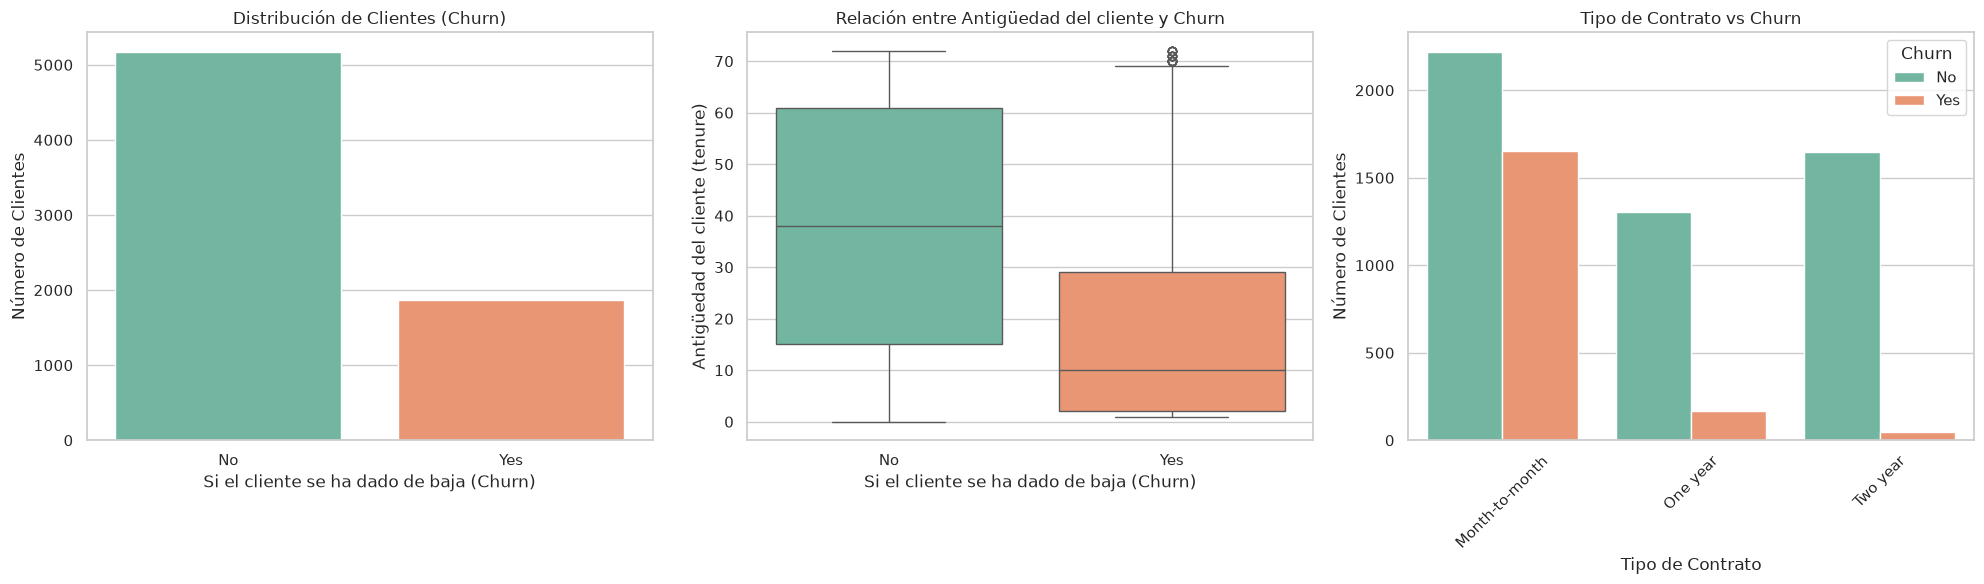

--- Resumen estadístico de las variables numéricas ---


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000



--- Proporción exacta de la variable objetivo (Churn) ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [4]:
# Crear un contenedeor para múltiples gráficos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Gráfico 1: Distribución de la Variable Objetivo (Churn) ---
# Nos permite ver si el dataset está balanceado o desbalanceado
sns.countplot(x='Churn', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Clientes (Churn)')
axes[0].set_xlabel('Si el cliente se ha dado de baja (Churn)')
axes[0].set_ylabel('Número de Clientes')

# --- Gráfico 2: Relación entre Antigüedad (tenure) y Churn ---
# Evaluamos si los clientes nuevos tienen mayor tendencia a irse
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Relación entre Antigüedad del cliente y Churn')
axes[1].set_xlabel('Si el cliente se ha dado de baja (Churn)')
axes[1].set_ylabel('Antigüedad del cliente (tenure)')

# --- Gráfico 3: Tipo de Contrato vs Churn ---
# Analizamos el impacto del tipo de contrato (Mensual, Anual, etc.) en la fuga
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Tipo de Contrato vs Churn')
axes[2].set_xlabel('Tipo de Contrato')
axes[2].set_ylabel('Número de Clientes')
axes[2].tick_params(axis='x', rotation=45)

# Ajustar el diseño para que no se superpongan los elementos
plt.tight_layout()
plt.show()

# Resumen numérico de las variables claves  
print("--- Resumen estadístico de las variables numéricas ---")
display(df.describe())

print("\n--- Proporción exacta de la variable objetivo (Churn) ---")
print(df['Churn'].value_counts(normalize=True) * 100)


Que se observa de los gráficos:
-	La distribución de los clientes, se pude apreciar la cantidad de clientes que no se fugan es mucho mayor que los que sí. Esta gran diferencia puede afectar los modelos mas adelante. 
-	El factor tiempo, el boxplot muestra que la mediana de antigüedad de los clientes fugados es muy baja.
-	La inmensa mayoría del Churn ocurre en contratos mensuales, lo que convierte a esta variable en un predictor crucial. 


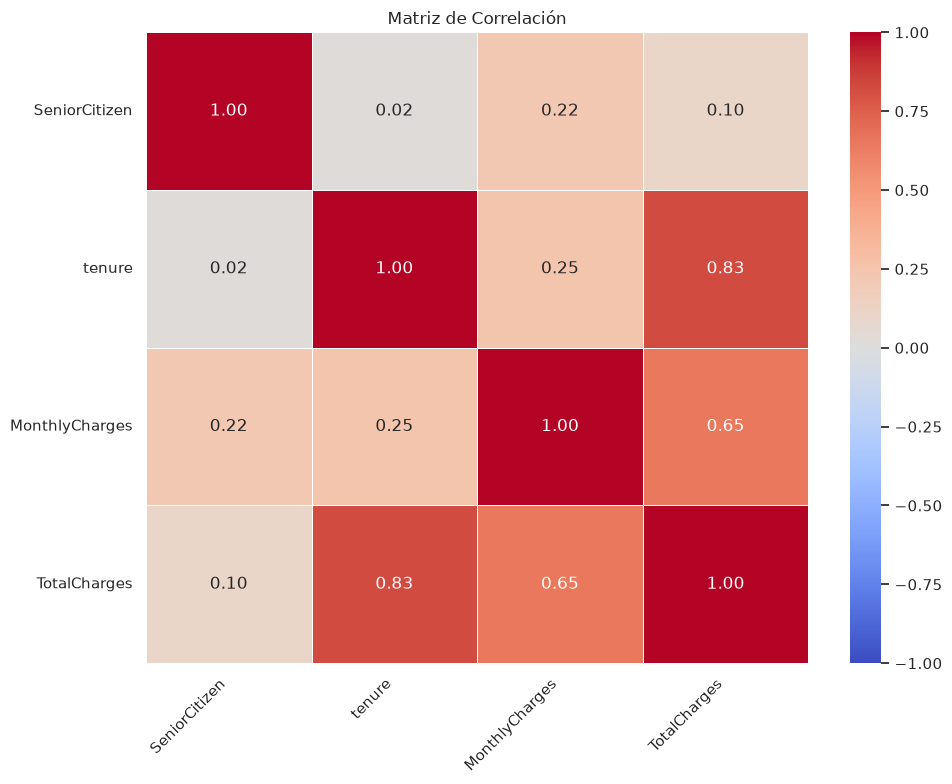

In [8]:
# Matriz de correlación
columnas = df.select_dtypes(include=[np.number]).columns

def matrizCorrelacion(columnas):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(numeric_only=True), 
                annot=True,
                fmt=".2f",
                cmap="coolwarm",
                linewidths=0.5,
                vmin=-1,
                vmax=1)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.title("Matriz de Correlación")
    plt.tight_layout()
    plt.show()

matrizCorrelacion(columnas)

# **Preprocesamiento de Datos y Feature Engineering**

In [5]:
# ==========================================
# Preprocesamiento Avanzado y Feature Engineering (Req. 2)
# ==========================================

# Crear una copia de seguridad para trabajar
df_clean = df.copy()

# TRATAMIENTO DE VALORES NULOS
nulos_totales = df_clean.isnull().sum()
print("\n--- Valores Nulos por Columna ---")
print(nulos_totales)



--- Valores Nulos por Columna ---
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [6]:
# Tratamiento de los valores nulos de TotalCharges
nulos_TotalCharges = df_clean['TotalCharges'].isnull().sum()

# Rellenamos con 0 los valores nulos de TotalCharges, ya que estos corresponden a clientes con tenure 0 (nuevos clientes)
if nulos_TotalCharges > 0:
    df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)
    print(f"\nSe han rellenado {nulos_TotalCharges} valores nulos en 'TotalCharges' con 0.")



Se han rellenado 11 valores nulos en 'TotalCharges' con 0.


In [7]:
# FEATURE ENGINEERING (Creación de nuevas variables)
# Contar el número de servicios adicionales que tiene el cliente
servicios_adicionales = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_clean['Num_Servicios_Adicionales'] = (df_clean[servicios_adicionales] == 'Yes').sum(axis=1)

# Crear una variable categórica para la antigüedad del cliente (tenure)
df_clean['Tenure_Group'] = pd.cut(df_clean['tenure'],
                                    bins=[-1, 12, 24, 48, 60, 100],
                                    labels=['0-1 Año', '1-2 Años', '2-4 Años', '4-5 Años', '+5 Años'])

In [8]:
# DETECCIÓN DE OUTLIERS (Método IQR en variables continuas)
def cap_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Tapar los valores atípicos (Capping)
    dataframe[column] = np.where(dataframe[column] > upper_bound, upper_bound,
                                 np.where(dataframe[column] < lower_bound, lower_bound, dataframe[column]))
    return dataframe

# Aplicar capping a las variables numéricas
for col in ['MonthlyCharges', 'TotalCharges']:
    df_clean = cap_outliers_iqr(df_clean, col)

In [10]:
# PREPARACIÓN FINAL (Drop, Encoding, Scaling)
if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop('customerID', axis=1)

X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Identificar tipos de datos actualizados
cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Num_Servicios_Adicionales']

# One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Escalado
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

# División (Estratificada por la variable objetivo)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print("\n✅ Preprocesamiento avanzado completado.")
print(f"Dimensiones de X_train: {X_train.shape}")

/tmp/ipykernel_1362/2275407748.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns



✅ Preprocesamiento avanzado completado.
Dimensiones de X_train: (5634, 35)


# **Entrenar al menos 3 algoritmos y optimizar sus hiperparametros**

Utilizaremos la técnica de Búsqueda en Cuadrícula con Validación Cruzada (GridSearchCV). Esto nos permite probar múltiples combinaciones de configuraciones (hiperparámetros) para cada algoritmo y elegir automáticamente la que mejor rinda.

Además, como descubrimos en el análisis exploratorio que hay un desbalance de clases (muchos más "No fugados" que "Fugados"), aplicaremos dos estrategias clave en este código:

- Le diremos a los algoritmos que presten más atención a la clase minoritaria usando class_weight='balanced'.

- Le pediremos a GridSearchCV que optimice buscando el mejor F1-Score en lugar de la precisión (Accuracy) general.

In [11]:
# ==========================================
# Entrenamiento y Optimización de Modelos (Req. 4)
# ==========================================
from sklearn.model_selection import GridSearchCV

# 1. Instanciar los modelos base
# Agregamos class_weight='balanced' para compensar el desbalance detectado en el EDA
models = {
    'Regresion_Logistica': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Arbol_Decision': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Naive_Bayes': GaussianNB()
}

# 2. Definir los "grids" (cuadrículas) de hiperparámetros a explorar para cada modelo
param_grids = {
    'Regresion_Logistica': {
        'C': [0.01, 0.1, 1, 10],            # Fuerza de la regularización
        'solver': ['liblinear', 'lbfgs']    # Algoritmo de optimización
    },
    'Arbol_Decision': {
        'max_depth': [3, 5, 7, 10, None],   # Profundidad máxima del árbol (evita sobreajuste)
        'min_samples_split': [2, 5, 10],    # Mínimo de muestras para dividir un nodo
        'criterion': ['gini', 'entropy']    # Función para medir la calidad de la división
    },
    'Naive_Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7] # Porción de la varianza mayor añadida a las varianzas
    }
}

# Diccionario para guardar los modelos ya entrenados con su mejor configuración
best_models = {}

print("Iniciando entrenamiento y optimización (esto puede tomar unos segundos)...\n")

# 3. Entrenar iterativamente cada modelo
for name in models.keys():
    print(f"Optimizando {name}...")
    
    # Configurar la validación cruzada (cv=5 significa que divide el X_train en 5 partes)
    grid = GridSearchCV(
        estimator=models[name], 
        param_grid=param_grids[name], 
        cv=5,          
        scoring='f1',  # Métrica clave para problemas de desbalance
        n_jobs=-1      # Usa todos los núcleos del procesador para ir más rápido
    )
    
    # Entrenar
    grid.fit(X_train, y_train)
    
    # Guardar el modelo ganador
    best_models[name] = grid.best_estimator_
    
    # Mostrar resultados
    print(f"✅ Mejor F1-Score (CV): {grid.best_score_:.4f}")
    print(f"   Mejores hiperparámetros: {grid.best_params_}\n")

print("¡Entrenamiento completado!")


Iniciando entrenamiento y optimización (esto puede tomar unos segundos)...

Optimizando Regresion_Logistica...
✅ Mejor F1-Score (CV): 0.6302
   Mejores hiperparámetros: {'C': 0.01, 'solver': 'lbfgs'}

Optimizando Arbol_Decision...
✅ Mejor F1-Score (CV): 0.6176
   Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 5}

Optimizando Naive_Bayes...
✅ Mejor F1-Score (CV): 0.5861
   Mejores hiperparámetros: {'var_smoothing': 1e-09}

¡Entrenamiento completado!


# **Evaluación de Modelos**

--- Reporte de Clasificación: Regresion_Logistica ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

----------------------------------------

--- Reporte de Clasificación: Arbol_Decision ---
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

----------------------------------------

--- Reporte de Clasificación: Naive_Bayes ---
              precision    recall  f1-score   support

           0       0.91      0.61      0.73      1035
    

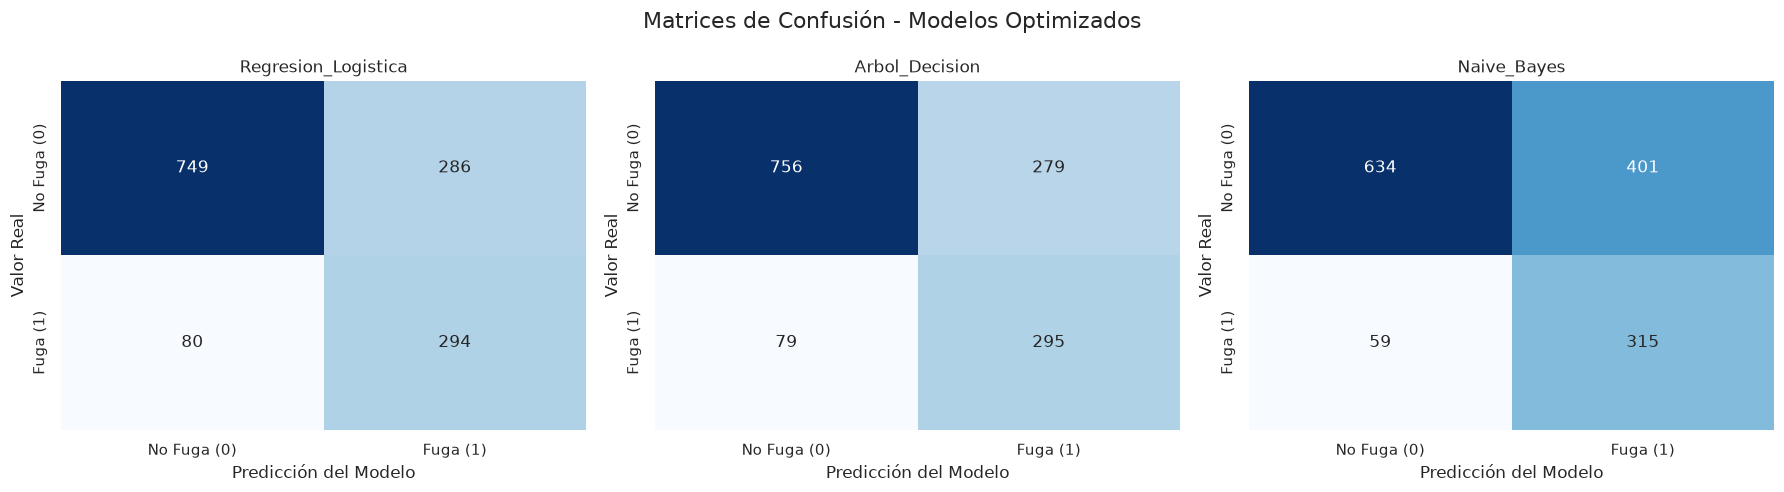


=== Tabla Resumen de Rendimiento ===


,Accuracy,Precision,Recall (Sensibilidad),F1-Score
Arbol_Decision,0.745919,0.513937,0.788770,0.622363
Regresion_Logistica,0.740241,0.506897,0.786096,0.616352
Naive_Bayes,0.673527,0.439944,0.842246,0.577982


In [12]:
# ==========================================
# Evaluación de Modelos
# ==========================================

# Preparar la figura para las matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusión - Modelos Optimizados', fontsize=16)

# Diccionario para guardar el resumen de métricas
resultados_metricas = {}

for idx, (name, model) in enumerate(best_models.items()):
    # 1. Hacer predicciones con los datos de prueba
    y_pred = model.predict(X_test)
    
    # 2. Calcular métricas clave
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Guardar para el resumen
    resultados_metricas[name] = {'Accuracy': acc, 'Precision': prec, 'Recall (Sensibilidad)': rec, 'F1-Score': f1}
    
    # 3. Mostrar el reporte de clasificación detallado
    print(f"--- Reporte de Clasificación: {name} ---")
    print(classification_report(y_test, y_pred))
    print("-" * 40 + "\n")
    
    # 4. Generar y graficar la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Predicción del Modelo')
    axes[idx].set_ylabel('Valor Real')
    axes[idx].set_xticklabels(['No Fuga (0)', 'Fuga (1)'])
    axes[idx].set_yticklabels(['No Fuga (0)', 'Fuga (1)'])

plt.tight_layout()
plt.show()

# ==========================================
# 8. Resumen Comparativo Final
# ==========================================
print("\n=== Tabla Resumen de Rendimiento ===")
df_resultados = pd.DataFrame(resultados_metricas).T
display(df_resultados.sort_values(by='F1-Score', ascending=False))